# Pie chart of mn counts

In [1]:
import os
import pandas as pd
import numpy as np
import skimage
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

- color schemes

In [8]:
datasets_colors = {'BBBC039':'#FFC0CB',
                   'mnfinder':'#80ED99',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

objects_color = {'Nuc':'#00A3FF',
                 'MN':'#A68CFF'}

# plt.rcParams.update({'font.size':12})

sns.set(font_scale=1.5, style='white')

- Count number of micronuclei annotations per each dataset

In [24]:
path = '/scr/data/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))
# df = df[df.split == 'train'] # only draw training set
df.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1


# Report total number of annotations

In [ ]:
labels = ['BBBC039', 'mnfinder_train', 'mnfinder_validation', 'mnfinder_test', 'mnDINO_data_01', 'mnDINO_data_02']
for label in labels:
    print(f'{label} has {df[df.datasets == label].shape[0]} images')

BBBC039 has 159 images
mnfinder_train has 30 images
mnfinder_validation has 3 images
mnfinder_test has 16 images
mnDINO_data_01 has 18 images
mnDINO_data_02 has 6 images


In [21]:
for subset in ['train', 'validation', 'test']:
    bbbc039_obj = 0
    mnfinder_obj = 0
    mndino_01_obj = 0
    mndino_02_obj = 0
    
    for i, row in df[df.split == subset].iterrows():
        filename = row.filenames.replace('.tif', '.png')
        im = skimage.io.imread(os.path.join('/scr/data/annotated_mn_datasets', subset, 'mn_masks', filename))
        labels = skimage.morphology.label(im)
        
        num_of_obj = np.max(labels)
        dataset = row.datasets
        
        if dataset == 'BBBC039':
            bbbc039_obj += num_of_obj
        elif dataset in ['mnfinder_train', 'mnfinder_validation', 'mnfinder_test']:
            mnfinder_obj += num_of_obj
        elif dataset == 'mnDINO_data_01':
            mndino_01_obj += num_of_obj
        elif dataset == 'mnDINO_data_02':
            mndino_02_obj += num_of_obj
    bbbc_imgs = df[(df.split == subset) & (df.datasets == 'BBBC039')].shape[0]
    mnfinder_imgs = df[(df.split == subset) & (df.datasets == f'mnfinder_{subset}')].shape[0]
    mndino_01_imgs = df[(df.split == subset) & (df.datasets == 'mnDINO_data_01')].shape[0]
    mndino_02_imgs = df[(df.split == subset) & (df.datasets == 'mnDINO_data_02')].shape[0]
    total_imgs = bbbc_imgs + mnfinder_imgs + mndino_01_imgs + mndino_02_imgs
    
    print('----------------------------------------------------------------------------------------------')
    print(f'BBBC039 ({subset}) has {bbbc_imgs} images and {bbbc039_obj} objects')
    print(f'MNFinder ({subset}) has {mnfinder_imgs} images and {mnfinder_obj} objects')
    print(f'mnDINO data 01 ({subset}) has {mndino_01_imgs} images and {mndino_01_obj} objects')
    print(f'mnDINO data 02 ({subset}) has {mndino_02_imgs} images and {mndino_02_obj} objects')
    print(f'Total has {total_imgs} and ({subset}) {bbbc039_obj + mnfinder_obj + mndino_01_obj + mndino_02_obj} objects')

----------------------------------------------------------------------------------------------
BBBC039 (train) has 77 images and 488 objects
MNFinder (train) has 30 images and 1749 objects
mnDINO data 01 (train) has 12 images and 1021 objects
mnDINO data 02 (train) has 2 images and 149 objects
Total has 121 and (train) 3407 objects
----------------------------------------------------------------------------------------------
BBBC039 (validation) has 39 images and 270 objects
MNFinder (validation) has 3 images and 180 objects
mnDINO data 01 (validation) has 3 images and 345 objects
mnDINO data 02 (validation) has 2 images and 245 objects
Total has 47 and (validation) 1040 objects
----------------------------------------------------------------------------------------------
BBBC039 (test) has 43 images and 255 objects
MNFinder (test) has 16 images and 473 objects
mnDINO data 01 (test) has 3 images and 322 objects
mnDINO data 02 (test) has 2 images and 188 objects
Total has 64 and (test) 

In [30]:
for i, row in df.iterrows():
    filename = row.filenames.replace('.tif', '.png')
    subset = row.split
    im = skimage.io.imread(os.path.join('/scr/data/annotated_mn_datasets', subset, 'mn_masks', filename))
    labels = skimage.morphology.label(im)
    num_of_mn = np.max(labels)
    df.loc[i, 'num_of_mn'] = num_of_mn

Subset: BBBC039, Total num of MN: 1013.0
Subset: mnfinder, Total num of MN: 2402.0
Subset: mnDINO_data_01, Total num of MN: 1688.0
Subset: mnDINO_data_02, Total num of MN: 582.0


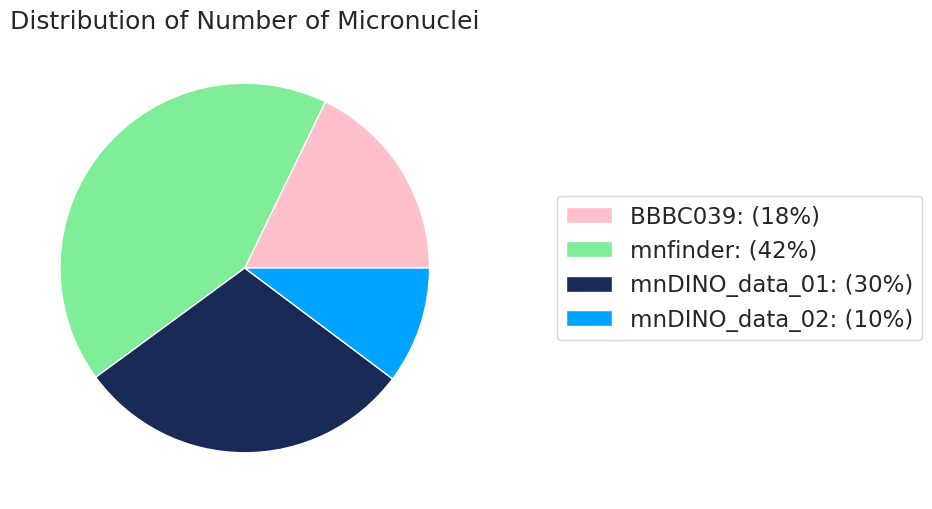

In [33]:
labels = ['BBBC039', 'mnfinder', 'mnDINO_data_01', 'mnDINO_data_02']
color_map_list = [datasets_colors[label] for label in labels]

counts = []

for subset in labels:
    if subset == 'mnfinder':
        total_mn = df.loc[df.datasets.isin(['mnfinder_train', 'mnfinder_validation', 'mnfinder_test']), 'num_of_mn'].sum()
    else:
        total_mn = df.loc[df.datasets == subset, 'num_of_mn'].sum()
    print(f'Subset: {subset}, Total num of MN: {total_mn}')
    counts.append(total_mn)

# customize legend
total = sum(counts)
percentages = [f'{c / total * 100:.0f}%' for c in counts]
legend_labels = [f'{label}: ({pct})' for label, pct in zip(labels, percentages)]

fig, ax = plt.subplots(figsize=(10, 6))
patches, texts = ax.pie(counts, labels=None, autopct=None, colors=color_map_list) # autopct=None to disable
ax.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1.15, 0.5))

plt.title('Distribution of Number of Micronuclei')
plt.show()

In [7]:
percentages

['14%', '51%', '30%', '4%']

# Count micronucleated cells

- Use Euclidean distance to find the nucleated cell ID, save the dataframe!

In [8]:
df[df.datasets == 'mnDINO_data_01']

,filenames,datasets,magnification,micron,split,cell_line
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa
12,20X_c0-DAPI_A1_Tile-70.tif,mnDINO_data_01,14,4.25,train,HeLa
13,20X_c0-DAPI_A1_Tile-110.tif,mnDINO_data_01,14,4.25,train,HeLa
14,20X_c0-DAPI_A1_Tile-10.tif,mnDINO_data_01,14,4.25,train,HeLa
16,C2-20X_c0-DAPI-GFP_B1_Tile-8.tif,mnDINO_data_01,14,4.25,train,HeLa
17,C2-20X_c0-DAPI-GFP_A3_Tile-6.tif,mnDINO_data_01,14,4.25,train,HeLa
18,C2-20X_c0-DAPI-GFP_A1_Tile-17.tif,mnDINO_data_01,14,4.25,train,HeLa
20,20X_c0-DAPI_A1_Tile-30.tif,mnDINO_data_01,14,4.25,train,HeLa


In [35]:
import numpy as np
import skimage.io
import skimage.measure
from scipy.spatial import KDTree
from skimage.measure import regionprops

DF_PATH = '/scr/data/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(DF_PATH, 'metadata.csv'))
all_cells = []

for i, row in tqdm(df.iterrows()):
    subset = row.datasets
    image_id = row.filenames
    subset = row.split
    PATH = f'/scr/data/annotated_mn_datasets/{subset}/mn_masks/'
    
    # for each image, identify number of nucleated cells and then move to next one
    mn_mask = skimage.io.imread(os.path.join(PATH, image_id.replace('.tif', '.png')))
    nuc_mask = skimage.io.imread(os.path.join(PATH.replace('mn_masks', 'nuclei_masks'), image_id))

    mn_labels = skimage.morphology.label(mn_mask)
    nuc_labels = skimage.morphology.label(nuc_mask)

    mn_props = regionprops(mn_labels)
    nuc_props = regionprops(nuc_labels)


    mn_centroids = np.array([prop.centroid for prop in mn_props])
    nuc_centroids = np.array([prop.centroid for prop in nuc_props])

    nuc_ids = np.array([prop.label for prop in nuc_props])

    tree = KDTree(nuc_centroids) # k=1 means find the single closest neighbor
    # print(image_id)
    distances, indices = tree.query(mn_centroids, k=1)
    matched_nuc_ids = nuc_ids[indices]


    final_matches = []

    for i, mn_prop in enumerate(mn_props):
        result = {
            'mn_id': mn_prop.label,
            'closest_nuc_id': matched_nuc_ids[i],
            'distance': distances[i]
        }
        final_matches.append(result)

    cells = []
    for match in final_matches:
        cells.append(match['closest_nuc_id'].item())
        

    num_nucleated_cells = len(np.unique(cells))
    d = {'filenames':image_id ,'datasets':subset, 'num_micronucleated_cells':num_nucleated_cells}
    all_cells.append(d)

micronucleated = pd.DataFrame(all_cells)

232it [00:10, 21.68it/s]


In [36]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/micronucleated_cells.csv'
micronucleated.to_csv(SAVE_PATH, index=False)

# Table of Statistics

In [38]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/micronucleated_cells.csv'
micronucleated = pd.read_csv(SAVE_PATH)
micronucleated

,filenames,datasets,num_micronucleated_cells
0,C1-20X_c0_B3_Tile-5.tif,train,61
1,C1-20X_c0_B3_Tile-24.tif,validation,139
2,C1-20X_c0_B3_Tile-15.tif,test,92
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,train,57
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,validation,63
...,...,...,...
227,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,train,5
228,IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A584...,test,9
229,IXMtest_I11_s6_w1B2DC04C7-2D7D-45C6-9DC2-66D86...,validation,3
230,IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BD...,validation,3


In [43]:
path = '/scr/data/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))

for i, row in tqdm(df.iterrows()):
    subset = row.datasets
    image_id = row.filenames
    subset = row.split
    PATH = f'/scr/data/annotated_mn_datasets/{subset}/'
    mn_mask = skimage.io.imread(os.path.join(PATH, 'mn_masks', image_id.replace('.tif', '.png')))
    mn_labels = skimage.measure.label(mn_mask)
    num_of_mn = np.max(mn_labels) # maximal label is the total number of micronuclei
    
    nuc_mask = skimage.io.imread(os.path.join(PATH, 'nuclei_masks', image_id))
    nuc_labels = skimage.measure.label(nuc_mask)
    num_of_nuclei = np.max(nuc_labels)
    
    df.loc[i, 'num_of_mn'] = num_of_mn
    df.loc[i, 'num_of_nuc'] = num_of_nuclei

232it [00:06, 36.90it/s] 


In [44]:
df.head()

,filenames,datasets,magnification,micron,split,cell_line,num_of_mn,num_of_nuc
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa,69.0,618.0
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa,170.0,1094.0
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa,117.0,558.0
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1,80.0,432.0
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1,75.0,482.0


In [53]:
# merge two dataframe by filenames column
table = df.merge(micronucleated[['filenames', 'num_micronucleated_cells']], on='filenames', how='left')

In [55]:
table = table.drop(columns=['filenames', 'magnification', 'micron', 'split', 'cell_line'])
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells
0,mnDINO_data_02,69.0,618.0,61
1,mnDINO_data_02,170.0,1094.0,139
2,mnDINO_data_02,117.0,558.0,92
3,mnDINO_data_02,80.0,432.0,57
4,mnDINO_data_02,75.0,482.0,63
...,...,...,...,...
231,BBBC039,5.0,125.0,5
232,BBBC039,10.0,139.0,9
233,BBBC039,4.0,61.0,3
234,BBBC039,3.0,101.0,3


In [56]:
table = table.groupby('datasets').sum().reset_index()
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells
0,BBBC039,1013.0,15718.0,849
1,mnDINO_data_01,1688.0,19852.0,1485
2,mnDINO_data_02,582.0,3600.0,471
3,mnfinder_test,555.0,617.0,292
4,mnfinder_train,1893.0,2332.0,1244
5,mnfinder_validation,243.0,294.0,184


In [57]:
table['micronucleation_ratio'] = table['num_micronucleated_cells'] / table['num_of_nuc']

In [74]:
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells,micronucleation_ratio
0,BBBC039,1013.0,15718.0,849,0.054015
1,mnDINO_data_01,1688.0,19852.0,1485,0.074804
2,mnDINO_data_02,582.0,3600.0,471,0.130833
3,mnfinder,555.0,617.0,292,0.473258
4,mnfinder,1893.0,2332.0,1244,0.533448
5,mnfinder,243.0,294.0,184,0.625850


In [75]:
table['datasets'] = table['datasets'].apply(lambda x: 'mnfinder' if 'mnfinder' in x else x)
aggregated_table = table.groupby('datasets')[['num_of_mn', 'num_of_nuc', 'num_micronucleated_cells']].sum().reset_index()
aggregated_table['micronucleation_ratio'] = aggregated_table['num_micronucleated_cells'] / aggregated_table['num_of_nuc']

aggregated_table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells,micronucleation_ratio
0,BBBC039,1013.0,15718.0,849,0.054015
1,mnDINO_data_01,1688.0,19852.0,1485,0.074804
2,mnDINO_data_02,582.0,3600.0,471,0.130833
3,mnfinder,2691.0,3243.0,1720,0.530373


In [3]:
TABLE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/table_statistics/table.csv'
# aggregated_table.to_csv(TABLE_PATH, index=False)

In [4]:
table = pd.read_csv(TABLE_PATH)
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells,micronucleation_ratio
0,BBBC039,1013.0,15718.0,849,0.054015
1,mnDINO_data_01,1688.0,19852.0,1485,0.074804
2,mnDINO_data_02,582.0,3600.0,471,0.130833
3,mnfinder,2691.0,3243.0,1720,0.530373


- Barplot

In [5]:
table_long = pd.melt(table.drop(columns=['num_of_mn', 'micronucleation_ratio']),
                     id_vars=['datasets'],
                     var_name='cell_status',
                     value_name='counts')

In [6]:
table_long

,datasets,cell_status,counts
0,BBBC039,num_of_nuc,15718.0
1,mnDINO_data_01,num_of_nuc,19852.0
2,mnDINO_data_02,num_of_nuc,3600.0
3,mnfinder,num_of_nuc,3243.0
4,BBBC039,num_micronucleated_cells,849.0
5,mnDINO_data_01,num_micronucleated_cells,1485.0
6,mnDINO_data_02,num_micronucleated_cells,471.0
7,mnfinder,num_micronucleated_cells,1720.0


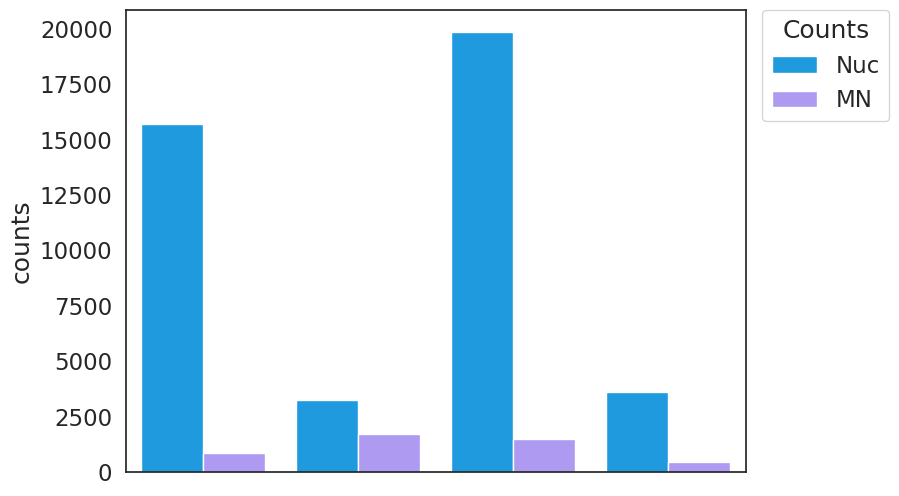

In [12]:
color_palette = {'num_of_nuc':objects_color['Nuc'], 'num_micronucleated_cells':objects_color['MN']}
labels = ['BBBC039', 'mnfinder', 'mnDINO_data_01', 'mnDINO_data_02']

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=table_long,
    x='datasets',
    y='counts',
    hue='cell_status',
    order=labels,
    palette=color_palette
)

# plt.xticks(rotation=45)
ax.set_xticks([])
plt.xlabel('')

# Change Title and Labels
sns.move_legend(
    ax, 
    loc="upper right",
    bbox_to_anchor=(1.25,1.025),
    title="Counts",
    # labels=["Cell Counts", "Micronucleated Cell Counts"],
    labels = ['Nuc', 'MN']
)

plt.show()

# Histogram of mn size v.s. nuclei size for each subset

In [90]:
path = '/scr/data/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))

In [96]:
df

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1
...,...,...,...,...,...,...
227,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,20,13.1,train,U2OS
228,IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A584...,BBBC039,20,13.1,test,U2OS
229,IXMtest_I11_s6_w1B2DC04C7-2D7D-45C6-9DC2-66D86...,BBBC039,20,13.1,validation,U2OS
230,IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BD...,BBBC039,20,13.1,validation,U2OS


In [97]:
all_data = []


for _, row in tqdm(df.iterrows()):
    label = row.datasets
    image_id = row.filenames
    subset = row.split
    PATH = f'/scr/data/annotated_mn_datasets/{subset}/'
    
    # for i in range(df_train.shape[0]):
    mn_mask = skimage.io.imread(os.path.join(PATH, 'mn_masks', image_id.replace('.tif', '.png')))
    nuc_mask = skimage.io.imread(os.path.join(PATH, 'nuclei_masks', image_id))
    
    mag = row.magnification
    micron = row.micron

    mn_labels = skimage.morphology.label(mn_mask)
    nuc_labels = skimage.morphology.label(nuc_mask)
        
    for mn_id in range(1, np.max(mn_labels) + 1):
        mn_area = np.sum(mn_labels == mn_id)
        all_data.append({"Dataset":label, "ImageID":image_id,"Type":"MN", "Area": int(mn_area), "Magnification":mag, "Micron":micron})
    
    for nuc_id in range(1, np.max(nuc_labels) + 1):
        ys, xs = np.where(nuc_labels == nuc_id)
        y, x = np.mean(ys), np.mean(xs)
        
        # filter out margin cases
        if not ((y - 25 <= 0) | (y + 25 >= nuc_mask.shape[0]) | (x - 25 <= 0) | (x + 25 >= nuc_mask.shape[1])):
            nuc_area = np.sum(nuc_labels == nuc_id)
            all_data.append({"Dataset":label, "ImageID":image_id,"Type":"Nuc", "Area": int(nuc_area), "Magnification":mag, "Micron":micron})
            

all_data = pd.DataFrame(all_data)

232it [12:01,  3.11s/it]


In [107]:
all_data['Dataset'] = all_data['Dataset'].apply(lambda x: 'mnfinder' if 'mnfinder' in x else x)

- Filter out nuclei area that is less than 10 $\text{pixel}^2$, consider them as artifact/noise

In [98]:
all_data = all_data[
    (all_data.Type == 'MN') | 
    ((all_data.Type == 'Nuc') & (all_data.Area > 10))
]

In [19]:
all_data[(all_data.Area < 5) & (all_data.Dataset.isin(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02']))]

,Dataset,ImageID,Type,Area,Magnification,Micron,Aligned_Area


In [17]:
all_data

,Dataset,ImageID,Type,Area,Magnification,Micron
0,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,42,20,6.5
1,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,134,20,6.5
2,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,117,20,6.5
3,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,73,20,6.5
4,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,58,20,6.5
...,...,...,...,...,...,...
42551,BBBC039,IXMtest_N15_s8_w16DBEFA45-FE5A-4233-A1B9-89CA8...,Nuc,720,20,13.1
42552,BBBC039,IXMtest_N15_s8_w16DBEFA45-FE5A-4233-A1B9-89CA8...,Nuc,678,20,13.1
42553,BBBC039,IXMtest_N15_s8_w16DBEFA45-FE5A-4233-A1B9-89CA8...,Nuc,654,20,13.1
42554,BBBC039,IXMtest_N15_s8_w16DBEFA45-FE5A-4233-A1B9-89CA8...,Nuc,810,20,13.1


In [18]:
all_data['Aligned_Area'] = all_data['Area'] * ((all_data['Micron'] / all_data['Magnification']) ** 2)

In [20]:
# Save area_distribution.csv
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/area_distribution.csv'
all_data.to_csv(SAVE_PATH, index=False)

In [21]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/area_distribution.csv'
all_data = pd.read_csv(SAVE_PATH)
all_data.head(3)

,Dataset,ImageID,Type,Area,Magnification,Micron,Aligned_Area
0,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,42,20,6.5,4.436250
1,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,134,20,6.5,14.153750
2,mnDINO_data_02,C1-20X_c0_B3_Tile-5.tif,MN,117,20,6.5,12.358125


- align data to our magnification (so the x-axis unit is micron)

Pixel Length ($\mu$ m/pixel) = Camera Pixel Size / Magnification

Pixel Area = $\text{Pixel Length}^{2}$

Text(0.5, 0, '')

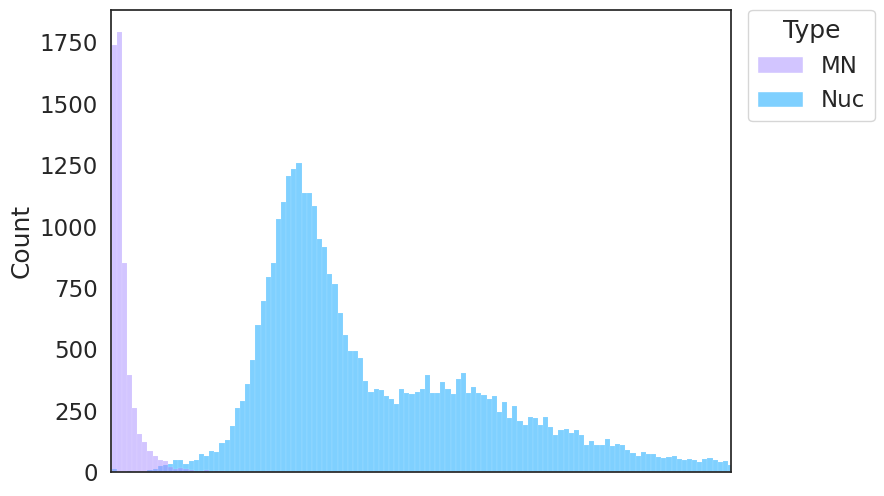

In [123]:
plt.figure(figsize=(8,6))
ax = sns.histplot(data=all_data, x="Aligned_Area", hue="Type", fill=True, bins=600, palette=objects_color)
# plt.xlabel('Cell Area')
plt.xlim(0, 500)
# plt.ylim(0, 1000)
sns.move_legend(obj=ax,
                loc='upper right',
                bbox_to_anchor=(1.25,1.025))

ax.set_xticks([])
ax.set_xlabel('')
# plt.title('Area Distributions aligned in microns')

In [39]:
all_data

,Dataset,ImageID,Type,Area,Magnification,Micron,Aligned_Area
0,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1,5.148300
1,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1,5.148300
2,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1,7.293425
3,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1,7.293425
4,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,16,20,13.1,6.864400
...,...,...,...,...,...,...,...
23374,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,287,20,13.0,121.257500
23375,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,502,20,13.0,212.095000
23376,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,278,20,13.0,117.455000
23377,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,567,20,13.0,239.557500


/tmp/ipykernel_4107713/3177583862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=all_data[all_data.Type=='MN'],


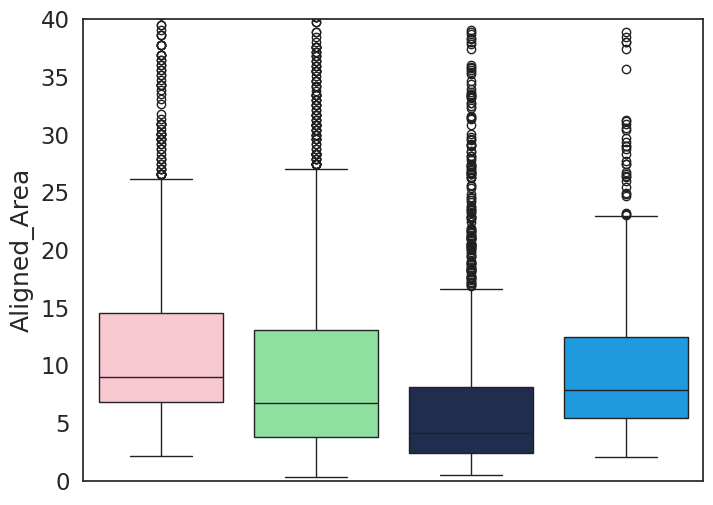

In [24]:
plt.figure(figsize=(8, 6))

ax = sns.boxplot(data=all_data[all_data.Type=='MN'],
            x='Dataset',
            y='Aligned_Area',
            order=['BBBC039', 'mnfinder', 'mnDINO_data_01', 'mnDINO_data_02'],
            palette=datasets_colors)

plt.ylim(0, 40)

# plt.xticks(rotation=45)
ax.set_xticks([])
ax.set_xlabel('')
# plt.title('Micronuclei Area Distributions aligned in micron')
# sns.move_legend(obj=ax,
#                 loc='upper right',
#                 bbox_to_anchor=(1.25,1.025))
plt.show()